# Results of SPARC pipeline experiments

This notebook reproduces the pipeline-level statistical analysis and quality-control figures reported in the manuscript (thoracic segmentation, reconstruction, reorientation, and end-to-end automation breakdown).

Part of the `sparc` package, by Arnaud Boutillon (arnaud.boutillon@kcl.ac.uk)

**On data.** This notebook operates on `csv/pipeline.csv`, a single de-identified, subject-level table of QC metrics and manual-review outcomes.

## Setup

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

notebook_dir = os.path.abspath("./")
csv_dir = os.path.join(notebook_dir, "csv")
plot_dir = os.path.join(notebook_dir, "plot")
df_path = os.path.join(csv_dir, "pipeline.csv")

## Plot utilities

In [2]:
def plot_qc_scatter(
        df, x, y, hue, xlabel, ylabel, xlim, ylim,
        xthresh, ythresh, fill_toward, legend_loc, plot_path,
    ):
    """Scatter plot of two inter-model QC metrics, coloured by manual
    review outcome, with the post-hoc acceptance region shaded.
    """
    fig = plt.figure()
    sns.scatterplot(data=df, x=x, y=y, hue=hue, legend="auto")

    y_edge = ylim[1] if fill_toward == "top" else ylim[0]
    plt.fill_between(
        [xlim[0], xthresh], ythresh, y_edge,
        alpha=0.25, color="green", label="Post-hoc\nacceptance\nregion",
    )

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xlim(xlim)
    plt.ylim(ylim)
    leg = plt.legend(loc=legend_loc, title=hue)
    leg._legend_box.align = "left"

    fig.tight_layout()
    os.makedirs(os.path.dirname(plot_path), exist_ok=True)
    plt.savefig(plot_path, bbox_inches="tight", dpi=300)
    plt.show() 

## 1. Cohort information

`EXCLUDED` marks subjects removed before pipeline reconstruction (e.g. insufficient usable stacks, or loss of Doppler gating during acquisition).

In [3]:
df = pd.read_csv(df_path)

n_total = df["subject_id"].nunique()
n_excluded = df[df["EXCLUDED"] == True]["subject_id"].nunique()
n_included = df[df["EXCLUDED"] == False]["subject_id"].nunique()

print(f"Total subjects: {n_total}")
print(f"Excluded subjects: {n_excluded}")
print(f"Included subjects: {n_included}")

Total subjects: 139
Excluded subjects: 18
Included subjects: 121


## 2. Pipeline experiments

### 2.1. Thoracic segmentation

Inter-model agreement (mean pairwise Dice / HD95 across the segmentation ensemble) against manual review outcome. The shaded region is the post-hoc QC acceptance region used in `monitored_auto` mode.

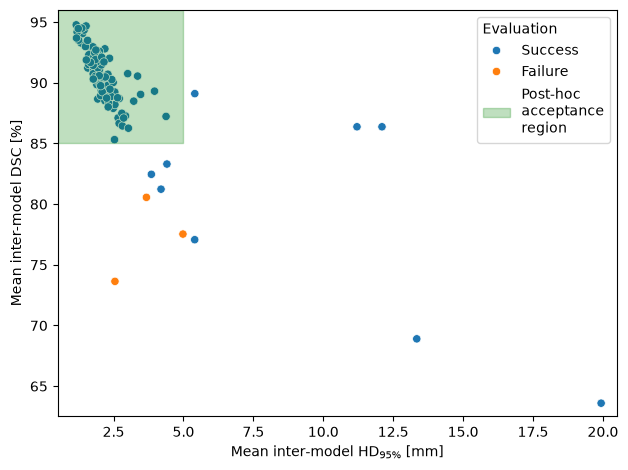

In [4]:
plot_path = os.path.join(plot_dir, "pipeline_chest_seg_qc.png")

df = pd.read_csv(df_path)
df = df[df["HEART_SEGMENTATION"] == True]

df.loc[df["MANUAL_CHEST_SEGMENTATION"] == 0.0, "Evaluation"] = "Success"
df.loc[df["MANUAL_CHEST_SEGMENTATION"] == 1.0, "Evaluation"] = "Failure"

plot_qc_scatter(
    df, x="CHEST_SEG_HD_QC", y="CHEST_SEG_DICE_QC", hue="Evaluation",
    xlabel=r"Mean inter-model $\mathrm{HD}_{95\%}$ [mm]",
    ylabel="Mean inter-model DSC [%]",
    xlim=[0.5, 20.5], ylim=[62.5, 96],
    xthresh=5.0, ythresh=85.0,
    fill_toward="top", legend_loc="upper right",
    plot_path=plot_path,
)

### 2.2. Reconstruction

Data-consistency metrics (NCC, NRMSE) and the fraction of slices SVR retained, split by whether the case passed cohort inclusion criteria or not (`EXCLUDED`).

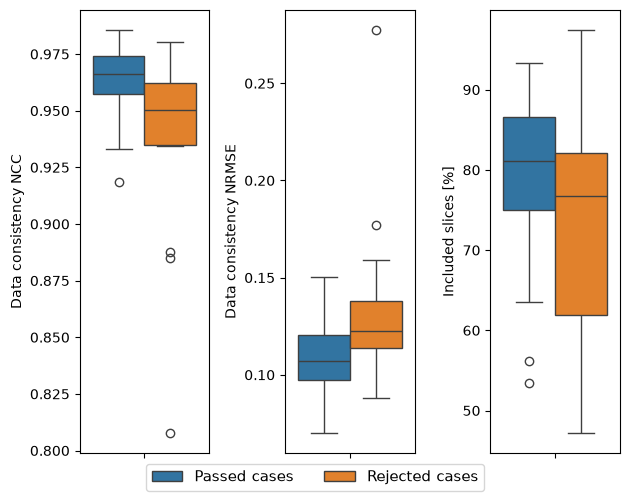

In [5]:
plot_path = os.path.join(plot_dir, "pipeline_recon_qc.png")

df = pd.read_csv(df_path)
df = df.drop(df[df["HEART_SEGMENTATION"] == False].index)

df["S_TOT"] = df["SVR_SE_QC"] + df["SVR_SI_QC"] + df["SVR_SO_QC"]
df["SVR_SI_QC"] /= df["S_TOT"] / 100 

df.loc[df["EXCLUDED"] == 0.0, "Evaluation"] = "Included"
df.loc[df["EXCLUDED"] == 1.0, "Evaluation"] = "Excluded"

metrics = ["SVR_NCC_QC", "SVR_NRMSE_QC", "SVR_SI_QC"]
labels = ["Data consistency NCC", "Data consistency NRMSE", r"Included slices [$\%$]"]

fig, axes = plt.subplots(1, 3)
for i, metric in enumerate(metrics):
    sns.boxplot(data=df, ax=axes[i], y=metric, hue="Evaluation", legend=False)
    axes[i].set_ylabel(labels[i])

fig.legend(
    labels=["Passed cases", "Rejected cases"],
    loc="lower center",
    ncol=2,
    bbox_to_anchor=(0.5, -0.05),
    frameon=True,
    fontsize=11,
)

fig.tight_layout()
os.makedirs(plot_dir, exist_ok=True)
plt.savefig(plot_path, bbox_inches="tight", dpi=300)
plt.show()

### 2.3. Reorientation

Success/failure counts split by whether cardiac localisation was used to constrain reorientation , then the corresponding QC acceptance-region plot for the with-localisation configuration.

In [6]:
df = pd.read_csv(df_path)

for cardiac_localisation in [False, True]:
    print(f"Cardiac localisation: {cardiac_localisation}")
    df_arm = df[df["HEART_SEGMENTATION"] == cardiac_localisation]
    df_success = df_arm[df_arm["MANUAL_REORIENTATION"] == False]
    df_failed = df_arm[df_arm["MANUAL_REORIENTATION"] == True]

    print(f"Success reorientation: {len(df_success)}")
    print(f"Failed reorientation: {len(df_failed)}\n")

Cardiac localisation: False
Success reorientation: 90
Failed reorientation: 31

Cardiac localisation: True
Success reorientation: 109
Failed reorientation: 12



Inter-model agreement (mean pairwise Geodesice dis / HD95 across the segmentation ensemble) against manual review outcome.

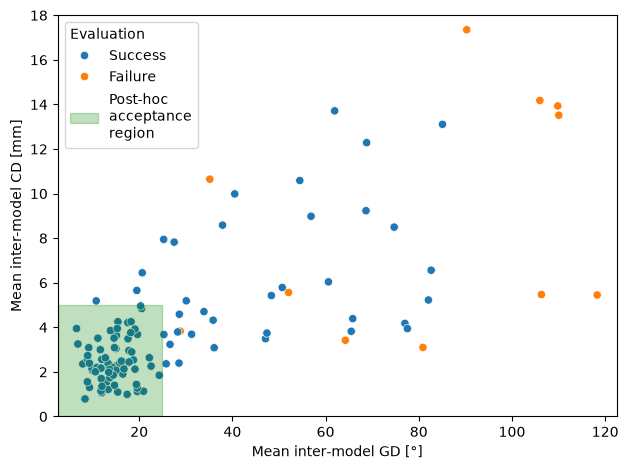

In [7]:
plot_path = os.path.join(plot_dir, "pipeline_reo_qc.png")

df = pd.read_csv(df_path)
df["REO_GD_QC"] = round(180 / np.pi * df["REO_GD_QC"], 4)  # radians -> degrees
df = df[df["HEART_SEGMENTATION"] == True]

df.loc[df["MANUAL_REORIENTATION"] == 0.0, "Evaluation"] = "Success"
df.loc[df["MANUAL_REORIENTATION"] == 1.0, "Evaluation"] = "Failure"

plot_qc_scatter(
    df, x="REO_GD_QC", y="REO_CD_QC", hue="Evaluation",
    xlabel=r"Mean inter-model GD [$\degree$]",
    ylabel="Mean inter-model CD [mm]",
    xlim=[2.5, 122.5], ylim=[0.0, 18],
    xthresh=25.0, ythresh=5.0,
    fill_toward="bottom", legend_loc="upper left",
    plot_path=plot_path,
)

### 2.4. Final breakdown

Full automation rate, the breakdown of which stage(s) required manual intervention when it wasn't fully automatic, and processing time.

In [8]:
df = pd.read_csv(df_path)
df = df[df["HEART_SEGMENTATION"] == True]

df_auto = df[df["MANUAL_INTERVENTION"] == False]
df_man = df[df["MANUAL_INTERVENTION"] == True]

print(f"Included subjects: {len(df)}")
print(f"Full-auto subjects: {len(df_auto)}")
print(f"Manual-intervention subjects: {len(df_man)}\n")

print(f"Manual stack exclusion: {len(df_man[df_man['MANUAL_STACK_EXCLUSION'] == True])}")
print(f"Manual template selection: {len(df_man[df_man['MANUAL_TEMPLATE_SELECTION'] == True])}")
print(f"Manual thorax segmentation: {len(df_man[df_man['MANUAL_CHEST_SEGMENTATION'] == True])}")
print(f"Manual pose estimation: {len(df_man[df_man['MANUAL_REORIENTATION'] == True])}\n")

print(f"Time SVR (s): {df_auto['SVR_TIME'].mean():.4f} ± {df_auto['SVR_TIME'].std():.4f}")
print(f"Time Pipeline (s): {df_auto['PIPELINE_TIME'].mean():.4f} ± {df_auto['PIPELINE_TIME'].std():.4f}")
svr_time = df_auto["SVR_TIME"] / df_auto["PIPELINE_TIME"] * 100
print(f"Time SVR (%): {svr_time.mean():.2f} ± {svr_time.std():.2f}")

Included subjects: 121
Full-auto subjects: 100
Manual-intervention subjects: 21

Manual stack exclusion: 6
Manual template selection: 3
Manual thorax segmentation: 3
Manual pose estimation: 12

Time SVR (s): 296.3167 ± 59.1406
Time Pipeline (s): 427.2236 ± 78.6305
Time SVR (%): 69.35 ± 5.31
